# Grounded Variance Commentary

**MAI 600 Natural Language Processing, Module 8 final project**
Lais Santos Silva

A month-end FP&A assistant that drafts variance commentary from retrieved evidence,
and declines to state a cause when the evidence does not support one.

## What this notebook demonstrates

The system separates three kinds of authority and lets the language model hold only
the last one.

| Authority | Source | The model's role |
|---|---|---|
| Numbers | A deterministic variance engine | Receives them as fact, forbidden to recompute |
| Rules | Retrieved policy documents | Cites the section, does not paraphrase the threshold |
| Causes | Retrieved driver memos | Cites the memo, or reports that no cause is supported |

Every figure in the article traces to a file in `results/`, and every one of those
files is written by code in this repository.

## Running it

1. Install dependencies: `pip install -r requirements.txt`
2. Start the local model server: `ollama serve`, then `ollama pull qwen3:4b-instruct`
3. Run all cells from the top.

Cells that call the model are guarded, so the notebook still runs top to bottom
without Ollama; the generation outputs are simply skipped.

---
## 0. Running this notebook

It runs unmodified in two places.

**Locally**, which is how the reported results were produced. The model server runs on
the same machine, so every cell executes including generation.

**In Google Colab**, where the cell below installs the dependencies and fetches the
project. Colab has no local model server, so the generation cells announce that and
skip, and the evaluation section reads the saved result files instead of regenerating
them. Everything else, including the corpus, the point-in-time filter, the variance
engine, retrieval, and the sufficiency gate, runs for real.

If you are in Colab and the project is not already beside this notebook, set `REPO_URL`
in the next cell to the published repository and run it again.

In [1]:
# ----------------------------------------------------------------- bootstrap
# Locates the project, and on Colab installs what is missing. Written so the same
# notebook runs in both places without edits.
import importlib.util, subprocess, sys
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None

# Set this once the repository is published, then Colab can fetch it on its own.
REPO_URL = None          # e.g. "https://github.com/<owner>/<repo>.git"
REPO_DIR = "mai600-module8-final-project"


def find_root(start: Path):
    """The project root is the nearest directory at or above `start` holding src/gvc."""
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "gvc").is_dir():
            return candidate
    return None


ROOT = find_root(Path.cwd())

if ROOT is None and IN_COLAB:
    if Path(REPO_DIR).is_dir():
        ROOT = find_root(Path(REPO_DIR).resolve())
    elif REPO_URL:
        print(f"fetching {REPO_URL}")
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
        ROOT = find_root(Path(REPO_DIR).resolve())

if ROOT is None:
    raise RuntimeError(
        "Could not locate the project. "
        "Locally, open this notebook from inside the project folder. "
        "In Colab, set REPO_URL above and run this cell again, or upload the project "
        f"so that {REPO_DIR}/src/gvc sits beside this notebook."
    )

if IN_COLAB:
    # faiss and sentence-transformers are imported by gvc.retrieval, so they must be
    # present before the next cell rather than at first use.
    print("installing dependencies, this takes a minute on a fresh Colab runtime")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "sentence-transformers", "faiss-cpu"], check=True)

sys.path.insert(0, str(ROOT / "src"))
DATA, RESULTS, IMAGES = ROOT / "data", ROOT / "results", ROOT / "images"

print(f"environment : {'Google Colab' if IN_COLAB else 'local'}")
print(f"project     : {ROOT.name}")

environment : local
project     : mai600-module8-final-project


---
## 1. Environment and setup

The whole system runs on the analyst's own machine. That is not a convenience: the
premise of the project is that pre-release financial figures must not leave the
organisation, and running locally turns that from an argument into a demonstration.

In [2]:
import platform, json

# ROOT, DATA, RESULTS, IMAGES and sys.path were established by the bootstrap cell
# above, so this cell only reports the environment and loads the project package.
import pandas as pd
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)

from gvc.cases import CONFIG_PERIODS, load_cases, periods
from gvc.corpus import admissible, load_corpus, month_end
from gvc.generate import DEFAULT_MODEL, ollama_available, run_B3, run_B4
from gvc.prompt import build_grounded_prompt
from gvc.retrieval import RetrievalConfig, Retriever
from gvc import harness

print(f"repository root : {ROOT.name}")
print(f"python          : {sys.version.split()[0]}")
print(f"platform        : {platform.platform()}")

OLLAMA_UP, ollama_msg = ollama_available(DEFAULT_MODEL)
print(f"model server    : {ollama_msg}")

repository root : mai600-module8-final-project
python          : 3.12.10
platform        : macOS-26.5.2-arm64-arm-64bit
model server    : ollama up, qwen3:4b-instruct present


---
## 2. Data: the synthetic corpus

Every document is invented. No real company's policies, memos, or figures appear
anywhere in the project, which is what makes it publishable as coursework.

The documents are written to mirror what a mid-size manufacturer actually produces at
close, so retrieval faces production difficulties rather than a tidy toy set:

- a policy that exists in two versions, one superseding the other
- memos published *after* the close they would explain
- near-duplicate memos about the wrong product line or the wrong region

Each document carries a version, a publication date, an effective window, an owner,
and an entity scope. Those fields are not decoration; the point-in-time filter in
section 3 is built entirely out of them.

In [3]:
docs, chunks = load_corpus(DATA / "corpus_documents.json")

print(f"{len(docs)} documents, {len(chunks)} retrievable sections\n")
summary = (chunks.groupby("category")
                 .agg(documents=("doc_id", "nunique"), sections=("doc_id", "size"))
                 .reset_index())
display(summary)

# load_corpus returns the raw document records plus the flattened section frame.
doc_table = pd.DataFrame(docs)[["doc_id", "doc_title", "category", "version",
                                "published_date", "effective_from",
                                "effective_to", "owner"]]
display(doc_table)

15 documents, 30 retrievable sections



,category,documents,sections
0,causes,9,17
1,distractor,2,2
2,precedent,1,2
3,rules,3,9


,doc_id,doc_title,category,version,published_date,effective_from,effective_to,owner
0,D01,Variance Commentary Policy,rules,v2.0,2022-12-15,2023-01-01,NaN,Group FP&A
1,D03,KPI and Metric Definitions Dictionary,rules,v1.4,2023-01-05,2023-01-01,NaN,Group FP&A
2,D04,Cost Centre Owner Register,rules,v3.1,2023-01-03,2023-01-01,NaN,Group FP&A
3,D11,Procurement Memo — Steel Index Movement,causes,v1.0,2023-06-12,2023-06-01,NaN,Procurement
4,D12,Sales Operations Memo — Tier-1 OEM Contract Non-Renewal,causes,v1.0,2023-11-08,2023-11-01,NaN,Sales Operations
5,D13,"Pricing Action Memo (v1.0, PROPOSED)",causes,v1.0,2024-01-10,2024-01-10,2024-01-25,Commercial
6,D14,"Pricing Action Memo (v2.0, APPROVED)",causes,v2.0,2024-01-25,2024-02-01,NaN,Commercial
7,D15,R&D Headcount Plan FY2024,causes,v1.0,2024-05-06,2024-05-01,NaN,R&D Finance
8,D16,Treasury Memo — EUR Exposure Update,causes,v1.0,2024-12-09,2024-12-01,NaN,Treasury
9,D17,Treasury Memo — Revolver Draw and Leverage Grid,causes,v1.0,2025-03-11,2025-03-01,NaN,Treasury


The `category` field is what splits the corpus into the two retrieval axes.

| category | axis | what it holds |
|---|---|---|
| `rules` | rules axis | policy, materiality thresholds, the cost-centre owner register |
| `causes` | causes axis | driver memos that explain one specific variance |
| `distractor` | causes axis | plausible memos about the wrong scope or the wrong period |
| `precedent` | excluded | prior-period commentary packs |

The `precedent` exclusion is a measured decision, not a preference. In Module 7 the
June 2023 commentary pack topped the causes axis in three of eight cases and appeared
in six, because a commentary pack is lexically similar to every variance question ever
asked. It is not a driver memo, so it does not belong on the causes axis at all.

In [4]:
policy = chunks[(chunks.doc_id == "D01") & (chunks.section.str.contains("4.2"))].iloc[0]
print(f"RULES EXAMPLE  {policy.doc_id} {policy.section}\n")
print(policy.chunk_text)

memo = chunks[chunks.doc_id == "D11"].iloc[0]
print(f"\n\nCAUSES EXAMPLE  {memo.doc_id} {memo.section}")
print(f"published {memo.published_date}, scope {memo.entity_scope}\n")
print(memo.chunk_text)

RULES EXAMPLE  D01 §4.2 Materiality Thresholds

Management commentary is required for a budget variance when EITHER of the following is met, measured at account and cost-centre level: (a) the absolute variance is at least USD 250,000 AND at least 5% of the budgeted amount; OR (b) the absolute variance is at least USD 500,000 regardless of percentage. Variances that meet neither condition are immaterial and must NOT receive commentary; commentary on an immaterial line is a reporting exception.


CAUSES EXAMPLE  D11 §1 Summary
published 2023-06-12, scope Drive Assemblies

To: Operations Controller. From: Procurement. Date: 12 June 2023. Subject: Steel index movement and impact on Drive Assemblies. The benchmark steel index rose 18% quarter-on-quarter, effective for June deliveries under our indexed supply contract.


---
## 3. Preprocessing: point-in-time admissibility

A document is retrievable for a given close only if

```
published_date <= close_date        and        close_date in [effective_from, effective_to)
```

This is the preprocessing step that most distinguishes a finance corpus from a general
one. Without it, the October 2025 inventory write-down memo would be retrievable when
answering a June 2023 question, and the system would look accurate while committing
lookahead leakage. Enforcing it in the retrieval mask rather than in the prompt means
no amount of prompt drift can reintroduce the leak.

In [5]:
probe = "D19"   # Operations memo, inventory write-down, published 2025-10-09
rows = []
for p in ("2023-06", "2024-05", "2025-06", "2025-10"):
    close = month_end(p)
    chunk = chunks[chunks.doc_id == probe].iloc[0]
    rows.append({"close_period": p, "close_date": close,
                 "D19_published": chunk.published_date,
                 "retrievable": admissible(chunk, close)})
display(pd.DataFrame(rows))

for p in ("2023-06", "2025-10"):
    close = month_end(p)
    n = sum(admissible(r, close) for _, r in chunks.iterrows())
    print(f"{p} close: {n} of {len(chunks)} sections admissible")

,close_period,close_date,D19_published,retrievable
0,2023-06,2023-06-30,2025-10-09,False
1,2024-05,2024-05-31,2025-10-09,False
2,2025-06,2025-06-30,2025-10-09,False
3,2025-10,2025-10-31,2025-10-09,True


2023-06 close: 12 of 30 sections admissible
2025-10 close: 29 of 30 sections admissible


The corpus grows over the evaluation window, which is what a real document set does.
An early close genuinely has less evidence available to it, so a retrieval failure in
2023-06 and one in 2025-10 do not mean the same thing.

---
## 4. The deterministic variance engine

The model computes nothing. Variance, variance percentage, the price / volume / mix
decomposition, and the materiality decision are all produced in Python and handed to
the model as verified fact.

Two materiality rules apply, both from the synthetic policy D01:

- **§4.2, dollar thresholds.** Commentary is required when the absolute variance is at
  least USD 250,000 *and* at least 5% of budget, or at least USD 500,000 regardless of
  percentage.
- **§4.3, covenant trigger.** Commentary is required, irrespective of dollars, for any
  movement that brings a lending covenant within 0.25 turns of EBITDA of its limit.

The covenant rule earns its place in the evaluation because it produces a case that
dollar thresholds get wrong: a USD 104,000 interest movement is immaterial in dollars
and reportable in substance.

In [6]:
cases = load_cases("periods")
print(f"{len(cases)} cases across {len(periods())} consecutive close periods")
print(f"config periods (never reported) : {list(CONFIG_PERIODS)}")
print(f"hold-out periods                : "
      f"{[p for p in periods() if p not in CONFIG_PERIODS]}\n")

tc = pd.read_csv(DATA / "test_cases.csv")
display(pd.crosstab(tc.stratum, tc.split, margins=True))

26 cases across 10 consecutive close periods
config periods (never reported) : ['2023-06', '2023-11']
hold-out periods                : ['2024-02', '2024-05', '2024-09', '2024-12', '2025-03', '2025-06', '2025-08', '2025-10']



split,config,holdout,All
stratum,,,
covenant,0,1,1
documented,2,4,6
evidence_less,2,6,8
immaterial,2,8,10
version_sensitive,0,1,1
All,6,20,26


In [7]:
documented = next(c for c in cases if c.case_id == "P2306-1")
print(f"{documented.case_id}  {documented.period}  {documented.account}\n")
for k, v in documented.verified_figures().items():
    print(f"  {k:24} {v}")

P2306-1  2023-06  5000 · Cost of Goods Sold

  period                   2023-06
  account                  5000 · Cost of Goods Sold
  cost_centre              CC-3100
  region                   North America
  product_line             Drive Assemblies
  actual                   5495000
  budget                   5000000
  variance_usd             495000
  variance_pct             9.9
  materiality_dollar_threshold 250000
  materiality_pct_threshold 5.0
  pct_threshold_usd        250000.0
  dollar_alone_threshold   500000


`pct_threshold_usd` is in that list deliberately. In Module 7 the model was told the
policy said "at least 5% of budget" and computed the dollar equivalent itself, which
is exactly the recomputation the design forbids. Supplying the derived threshold as a
verified figure removes the reason to derive one.

In [8]:
covenant = next(c for c in cases if c.materiality_trigger == "covenant")
print(f"{covenant.case_id}  {covenant.period}  {covenant.account}")
print(f"  variance            ${covenant.variance_usd:,.0f} "
      f"({covenant.variance_pct:+.1f}%)")
print(f"  covenant headroom   {covenant.covenant_headroom} turns of EBITDA")
print(f"  commentary required {covenant.commentary_required}  "
      f"via {covenant.materiality_trigger}")
print("\nBelow both dollar thresholds, and still reportable. A dollar-only rule "
      "would have missed it.")

P2503-1  2025-03  7000 · Interest Expense
  variance            $104,000 (+10.0%)
  covenant headroom   0.1 turns of EBITDA
  commentary required True  via covenant

Below both dollar thresholds, and still reportable. A dollar-only rule would have missed it.


---
## 5. RAG setup: two axes over disjoint sub-corpora

The rules axis and the causes axis search different parts of the corpus with separate
top-k budgets. A single ranked list would let a strong policy match consume the whole
budget and leave no room for the memo that actually explains the variance, or the
reverse.

Embeddings come from `all-MiniLM-L6-v2` and the index is FAISS inner product over
normalised vectors, so the score is cosine similarity.

In [9]:
import warnings
warnings.filterwarnings("ignore", message=".*IProgress.*")

from sentence_transformers import SentenceTransformer

embed = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# The configuration reported throughout. Chosen on the config periods only.
CONFIG = RetrievalConfig(k_rules=2, k_causes=3, exclude_precedent=True,
                         tau=0.25, require_scope_match=True)
retriever = Retriever(chunks, embed, CONFIG)
print(f"embedded {retriever.embeddings.shape[0]} sections "
      f"into {retriever.embeddings.shape[1]} dimensions")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9172.84it/s]

embedded 30 sections into 384 dimensions


In [10]:
q_rules, q_causes = Retriever.queries_for(documented)
print(f"rules query  : {q_rules}")
print(f"causes query : {q_causes}\n")

rules, causes = retriever.retrieve(documented)
print("RULES AXIS")
display(rules[["rank", "doc_id", "section", "score"]].round({"score": 3}))
print("CAUSES AXIS")
display(causes[["rank", "doc_id", "category", "entity_scope", "score"]]
        .round({"score": 3}))
print(f"planted source for this case: {documented.gold_doc}  "
      f"(evaluation only, never shown to the model)")

rules query  : materiality threshold commentary requirement owner 5000 · Cost of Goods Sold CC-3100 variance
causes query : 5000 · Cost of Goods Sold CC-3100 North America Drive Assemblies 2023-06 driver cause change explanation

RULES AXIS


,rank,doc_id,section,score
0,1,D01,§4.2 Materiality Thresholds,0.455
1,2,D04,Register — Sales and Commercial,0.391


CAUSES AXIS


,rank,doc_id,category,entity_scope,score
0,1,D11,causes,Drive Assemblies,0.513
1,2,D32,distractor,Precision Fittings,0.354


planted source for this case: D11  (evaluation only, never shown to the model)


---
## 6. The sufficiency gate

Abstention is decided before generation, not requested during it. A generator handed a
"why" question will nearly always produce a why, so asking the model to abstain puts
the safety property in the least reliable place in the system.

The gate passes only when some retrieved driver clears the similarity floor and matches
the row's entity scope. It scans every retrieved driver rather than only the top one,
because the supporting memo frequently sits at rank 2 or 3 behind a higher-scoring but
irrelevant document.

In [11]:
evidence_less = next(c for c in cases if c.stratum == "evidence_less")

for case in (documented, evidence_less):
    _, cz = retriever.retrieve(case)
    ok, why = retriever.sufficient(case, cz)
    print(f"{case.case_id}  {case.stratum:14}  gate={'PASS' if ok else 'ABSTAIN'}")
    print(f"    {why}")
    print(f"    retrieved: {list(cz.doc_id)}\n")

P2306-1  documented      gate=PASS
    sufficient (D11 at 0.513)
    retrieved: ['D11', 'D32']

P2306-3  evidence_less   gate=ABSTAIN
    no driver clears tau 0.25 (best 0.182)
    retrieved: ['D11', 'D32']



---
## 7. Generation

The prompt states the verified figures as fact and forbids recomputation, then presents
the two retrieved axes separately so the model can cite a policy section and a driver
memo as distinct sources.

In [12]:
prompt_text = build_grounded_prompt(documented, rules, causes)
print(f"prompt length: {len(prompt_text):,} characters\n")
print(prompt_text[:1600])
print("\n... [truncated]")

prompt length: 2,924 characters

  SYSTEM
  You write month-end variance commentary for an FP&A team.

  ABSOLUTE RULES
  1. NEVER calculate, estimate, or restate a number. Every figure you may use is
     supplied under VERIFIED FIGURES, including the materiality thresholds.
     Reproduce them exactly. If a figure you need is not supplied, say so.
  2. State a cause ONLY if a DRIVER EVIDENCE passage supports it. If none does,
     set the cause to "unsupported" and escalate to the cost-centre owner. An
     unsupported cause is a more serious error than no cause at all.
  3. Every factual sentence carries a citation [n] resolving to a passage below.
  4. Apply the materiality rule as written in POLICY and cite the clause used.
  5. No speculation and no recommendations beyond the escalation path.

  VERIFIED FIGURES  (authority: variance engine, treat as fact)
    period: 2023-06
account: 5000 · Cost of Goods Sold
cost_centre: CC-3100
region: North America
product_line: Drive Assembl

In [13]:
if OLLAMA_UP:
    g = run_B3(documented, retriever=retriever)
    print(f"{g.case_id}  documented case   {g.seconds:.2f}s\n")
    print(g.answer)
else:
    print("Ollama unavailable; skipping generation.")

P2306-1  documented case   2.98s

Headline: Variance of $495,000 (+9.9%) [n]  
Cause: Steel index increase directly impacting Drive Assemblies unit cost [n]  
Accountable owner: Not specified (escalate to cost-centre owner) [n]  
Citations: [3] D11 §2, [1] D01 §4.2 (a) and (b) — variance exceeds both dollar and percentage materiality thresholds.


In [14]:
if OLLAMA_UP:
    g = run_B4(evidence_less, retriever=retriever)
    print(f"{g.case_id}  evidence-less case   gate_passed={g.gate_passed}\n")
    print(g.answer)
    print("\nNo cause is invented. The line is escalated instead.")
else:
    print("Ollama unavailable; skipping generation.")

P2306-3  evidence-less case   gate_passed=False

6100 · Legal & Professional variance $635,000 (+100.3%) in 2023-06 [1]. Cause: unsupported, no admissible driver evidence retrieved (no driver clears tau 0.25 (best 0.182)). Escalate to the cost-centre owner. Owner per D04 Register — General and Administrative.

No cause is invented. The line is escalated instead.


---
## 8. Evaluation on the hold-out periods

The configuration above was chosen using only the two earliest closes. Everything
reported from here uses the eight later closes, which the configuration never saw.

This matters more than it might appear. An earlier candidate configuration scored a
perfect 4 out of 4 on the config periods and then abstained on 100% of the hold-out
cases, because its absolute similarity threshold happened to sit just above the score
range of the corpus. Reporting on the cases used to configure would have presented that
as a success.

Four metrics are recorded. The last two are a pair and are never reported separately,
because a system that abstains on everything scores 100% on correct abstention alone.

1. **Retrieval hit@3**, whether the planted source document appears in the causes axis
2. **Numeric fidelity**, whether every figure in the output traces to a verified figure
   or to retrieved text
3. **Correct abstention**, on cases where no supporting memo exists
4. **Over-abstention**, on cases where retrieval actually succeeded

Numeric fidelity is reported at two scopes, and the difference between them turned out to
matter. Restricted to documented cases it answers "when the system states a cause, are its
figures sound". That scope cannot see a figure invented on a case that abstained, because
an abstaining case has no planted source and drops out of the measure. Widening it to
every case that produced text exposes one B3 output that abstained correctly and still
mentioned a dollar amount from nowhere, and it drops the long-context arm from a perfect
score to 50%.

In [15]:
holdout = load_cases("holdout")
print(f"{len(holdout)} hold-out cases across "
      f"{len({c.period for c in holdout})} closes")

if OLLAMA_UP:
    b3 = pd.DataFrame(harness.run_arm("B3", holdout, retriever, chunks))
    display(harness.summarise(b3))
else:
    b3 = pd.read_csv(RESULTS / "evaluation_scores.csv").query("arm == 'B3'")
    print("Ollama unavailable; reading the saved run instead.")
    display(harness.summarise(b3))

20 hold-out cases across 8 closes


,arm,cases,retrieval_hits,retrieval_rate,numeric_fidelity,numeric_fidelity_all,abstention_correct,over_abstention,mean_seconds
0,B3,20,4/6,0.667,6/6,11/12,6/6,0/4,0.92


In [16]:
display(b3[b3.gold_doc.notna()][
    ["case_id", "period", "account", "gold_doc", "retrieval_hit",
     "numeric_fidelity", "abstained"]])

,case_id,period,account,gold_doc,retrieval_hit,numeric_fidelity,abstained
0,P2402-1,2024-02,4000 · Revenue,D14,True,True,False
3,P2405-1,2024-05,6500 · R&D Operating Expense,D15,True,True,False
9,P2412-1,2024-12,4000 · Revenue,D16,True,True,False
11,P2503-1,2025-03,7000 · Interest Expense,D17,True,True,False
15,P2508-1,2025-08,4000 · Revenue,D18,False,True,True
17,P2510-1,2025-10,5000 · Cost of Goods Sold,D19,False,True,True


Retrieval is where the system is weakest, and the important observation is what happens
downstream of a retrieval miss. On the cases where the planted memo was not retrieved,
the output is not a wrong cause; it is an abstention. The failure mode degrades into
the safe direction, which for month-end reporting is the difference between a usable
system and an unusable one.

---
## 9. Month-over-month replication

The evaluation is organised as consecutive monthly closes rather than as a set of
probes, because the operational question is not "can it explain one variance" but
"does it behave the same way next month, against a document set that has grown".

In [17]:
per = []
for p in periods():
    if p in CONFIG_PERIODS:
        continue
    g = b3[b3.period == p]
    if len(g) == 0:
        continue
    gold, ev = g[g.gold_doc.notna()], g[g.stratum == "evidence_less"]
    per.append({
        "period": p,
        "cases": len(g),
        "retrieval": f"{int(gold.retrieval_hit.sum())}/{len(gold)}" if len(gold) else "n/a",
        "correct_abstention": f"{int(ev.abstained.sum())}/{len(ev)}" if len(ev) else "n/a",
        "numeric_fidelity": f"{int(g.numeric_fidelity.sum())}/{len(g)}",
    })
per_period = pd.DataFrame(per)
display(per_period)

,period,cases,retrieval,correct_abstention,numeric_fidelity
0,2024-02,3,1/1,1/1,3/3
1,2024-05,3,1/1,1/1,3/3
2,2024-09,3,n/a,2/2,2/3
3,2024-12,2,1/1,n/a,2/2
4,2025-03,2,1/1,n/a,2/2
5,2025-06,2,n/a,1/1,2/2
6,2025-08,2,0/1,n/a,2/2
7,2025-10,3,0/1,1/1,3/3


Numeric fidelity and abstention hold across every close. Retrieval does not, and the
periods where it fails are the ones whose supporting memo competes with a
near-duplicate distractor. That is a corpus-level property rather than a per-period
accident, which is the useful thing to learn from running the same system ten times.

---
## 10. Baseline ladder

Five arms answer the question a reviewer should ask, which is whether the retrieval
machinery earns its complexity.

| Arm | What it is | What it isolates |
|---|---|---|
| B0 | Deterministic template, no model | Whether a language model is needed at all |
| B1 | Verified figures, no retrieval | What the model invents when unconstrained |
| B2 | Whole corpus in the prompt | Whether retrieval beats long context |
| B3 | Two-axis filtered retrieval | The proposed system |
| B4 | B3 plus the pre-generation gate | Whether the gate adds anything over B3 |

The full ladder is produced by `build/run_experiments.py`, which takes a few minutes.
Its output is read here rather than re-run, so this notebook stays quick.

In [18]:
ladder = pd.read_csv(RESULTS / "benchmark_results.csv")
display(ladder)

,arm,cases,retrieval_hits,retrieval_rate,numeric_fidelity,numeric_fidelity_all,abstention_correct,over_abstention,mean_seconds
0,B0,20,NaN,NaN,6/6,12/12,0/6,NaN,0.00
1,B1,20,NaN,NaN,5/6,9/12,0/6,NaN,0.39
2,B2,20,NaN,NaN,6/6,6/12,0/6,NaN,1.80
3,B3,20,4/6,0.667,6/6,11/12,6/6,0/4,0.75
4,B4,20,4/6,0.667,6/6,12/12,6/6,0/4,0.31


B0 is the honest control and it is not embarrassing: a template gets every number right,
because no number ever came from the model. What it cannot do is state a cause, which is
the entire deliverable of month-end commentary. It abstains on nothing and explains
nothing.

B1 shows the failure the project exists to prevent. Given the same verified figures and
no evidence, the model supplies a fluent cause anyway, and on three cases it supplies
figures that exist in no source at all.

B2 is the result that most surprised me, and it is the clearest argument in the study for
retrieval over long context. Scored only on documented cases it looks perfect, at 6 of 6.
Scored on every case that produced text it falls to 6 of 12, because with the whole
corpus in the prompt the model repeatedly imports the steel-index figures from D11, the
June 2023 memo, into commentary about entirely different accounts and periods. It is also
the slowest arm. Retrieval is not merely a cheaper way to reach the same context; the
filtering is doing safety work that a bigger context window does not do.

B4 beats B3 on that same wide measure, 12 of 12 against 11 of 12, and it is the faster of
the two because a gated case never reaches the model. The single B3 miss is instructive:
the model abstained correctly and then mentioned a figure that appears nowhere in its
sources. B4's post-generation verifier catches exactly that.

---
## 11. Improvement over the Module 7 prototype

Every "before" value below is read from the Module 7 result files and every "after"
value from the Module 8 result files. Nothing is transcribed by hand.

In [19]:
imp = pd.read_csv(RESULTS / "improvement_comparison.csv")
display(imp)

,Area,Module 7 prototype,Module 8 final,Evidence
0,Retrieval hit rate (same hold-out cases),2/6 (33%),4/6 (67%),results/retrieval_config_comparison.csv; precedent documents excluded from the causes ...
1,Numeric fidelity,4/5 (C3 derived a threshold),6/6,"materiality thresholds now supplied as verified figures, so the model has no reason to..."
2,Correct abstention,2/2,6/6,"evidence-less stratum grown from 2 cases to 8, of which 6 fall in the hold-out periods..."
3,Over-abstention (abstained with evidence present),not measured,0/4,metric added; measuring only correct abstention had hidden a gate that abstained on ev...
4,Test cases,8 hand-picked,20 across 8 consecutive close periods,data/test_cases.csv
5,Comparison arms,1 (B3 only),5 (B0 to B4),results/benchmark_results.csv
6,Validation design,"none, configured and reported on the same cases","temporal split, configured on 2 periods and reported on 8",an absolute threshold scored 4/4 on the config periods and then failed on 100% of hold...
7,Corpus,12 documents,15 documents,"D16 FX, D17 revolver and covenant, D18 stale launch brief added"
8,Materiality rules,dollar thresholds only,dollar thresholds plus the covenant trigger,D01 4.3; a $104K interest movement is immaterial in dollars yet reportable on covenant...
9,Serving and speed,"Colab VM, 142.19s per case","local Ollama, 1.25s per case","the deployment premise is that pre-release figures do not leave the organisation, now ..."


In [20]:
cfgcmp = pd.read_csv(RESULTS / "retrieval_config_comparison.csv")
display(cfgcmp)

,config,hits,n,rate,misses
0,Module 7 baseline,2,6,0.333,"P2402-1, P2412-1, P2508-1, P2510-1"
1,Module 8 principled,4,6,0.667,"P2508-1, P2510-1"
2,k=4 variant (tuned),5,6,0.833,P2508-1


The retrieval comparison is run on the same hold-out cases under both configurations,
so the improvement is a like-for-like measurement rather than a change of test set.

The `k=4` variant scores higher still. It is reported and labelled as tuned, because
its only justification was that it captured a gold document in a case whose failure had
already been inspected. The `precedent` exclusion is reported as the headline result
instead, because it is a category correction that would have been correct without ever
looking at the outcome.

---
## 12. Figures

system_architecture.png


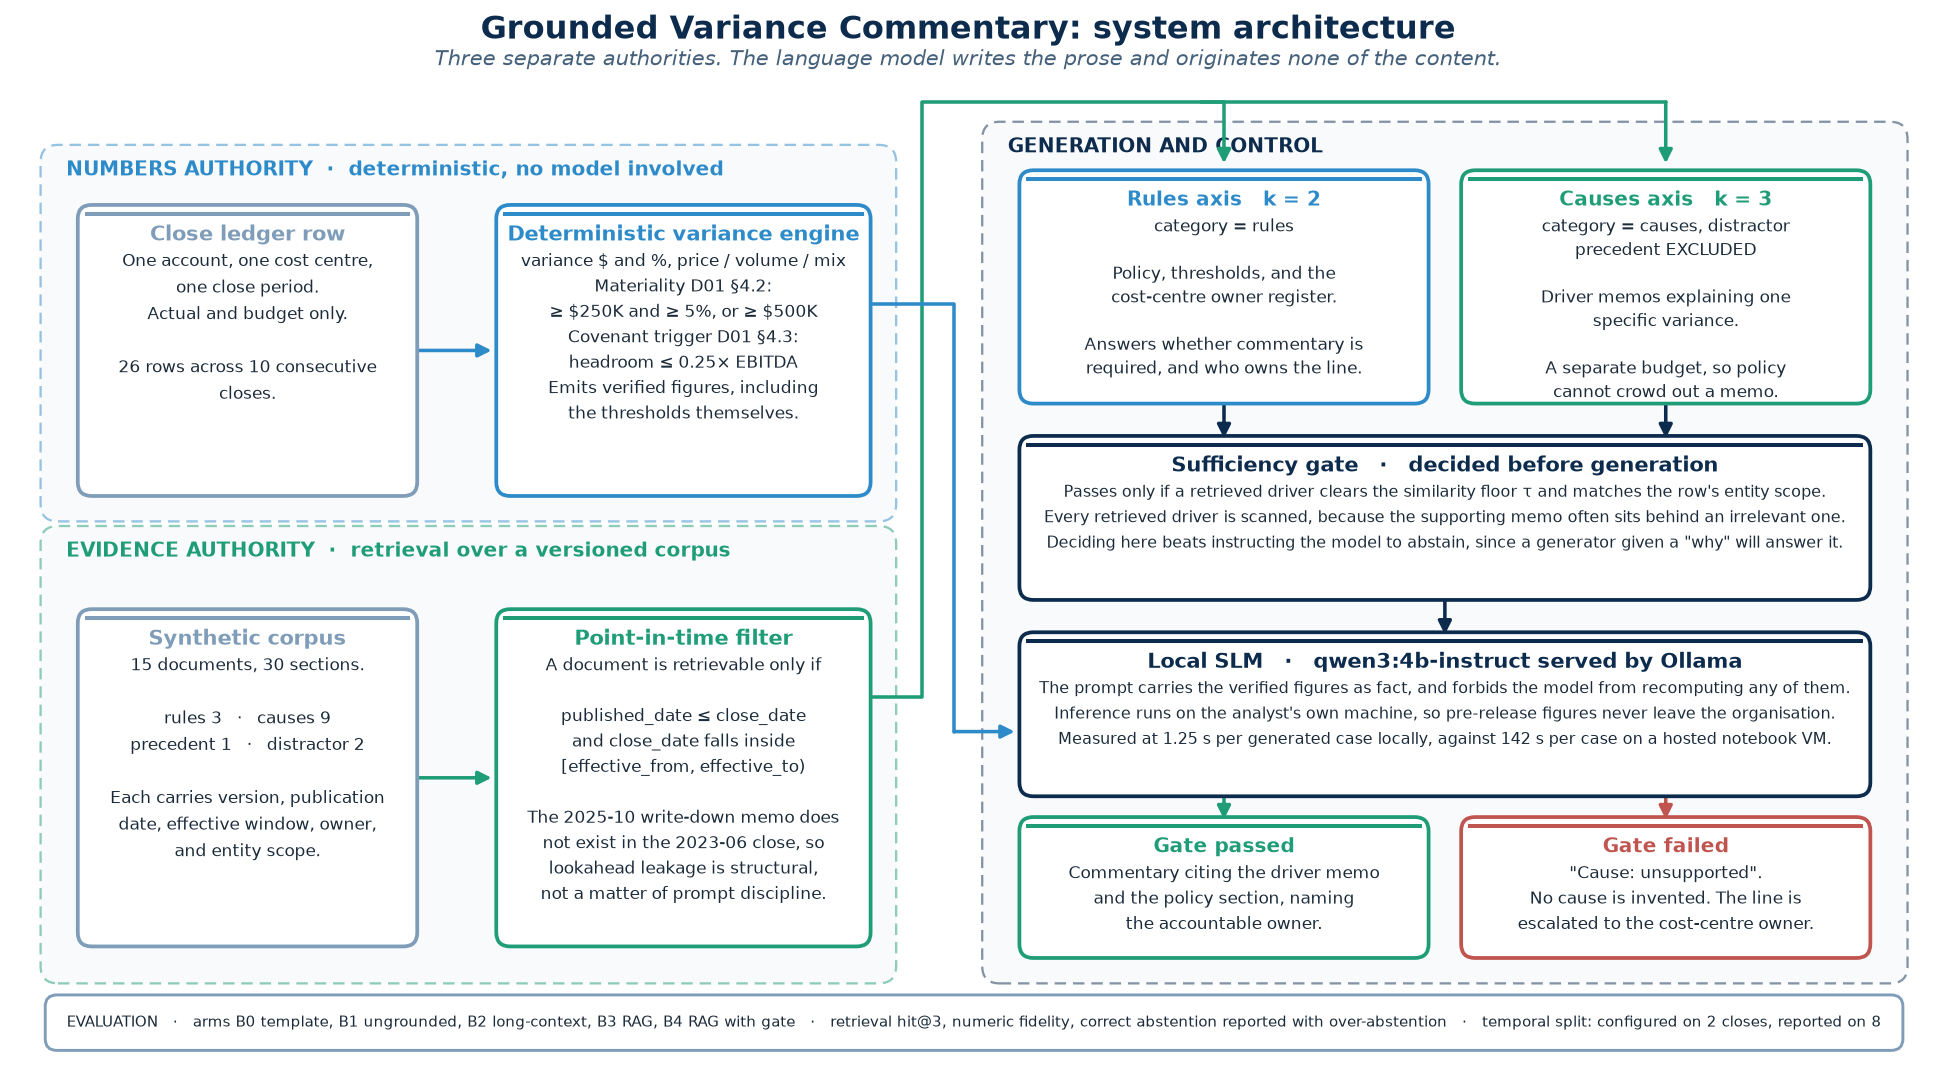

evaluation_chart.png


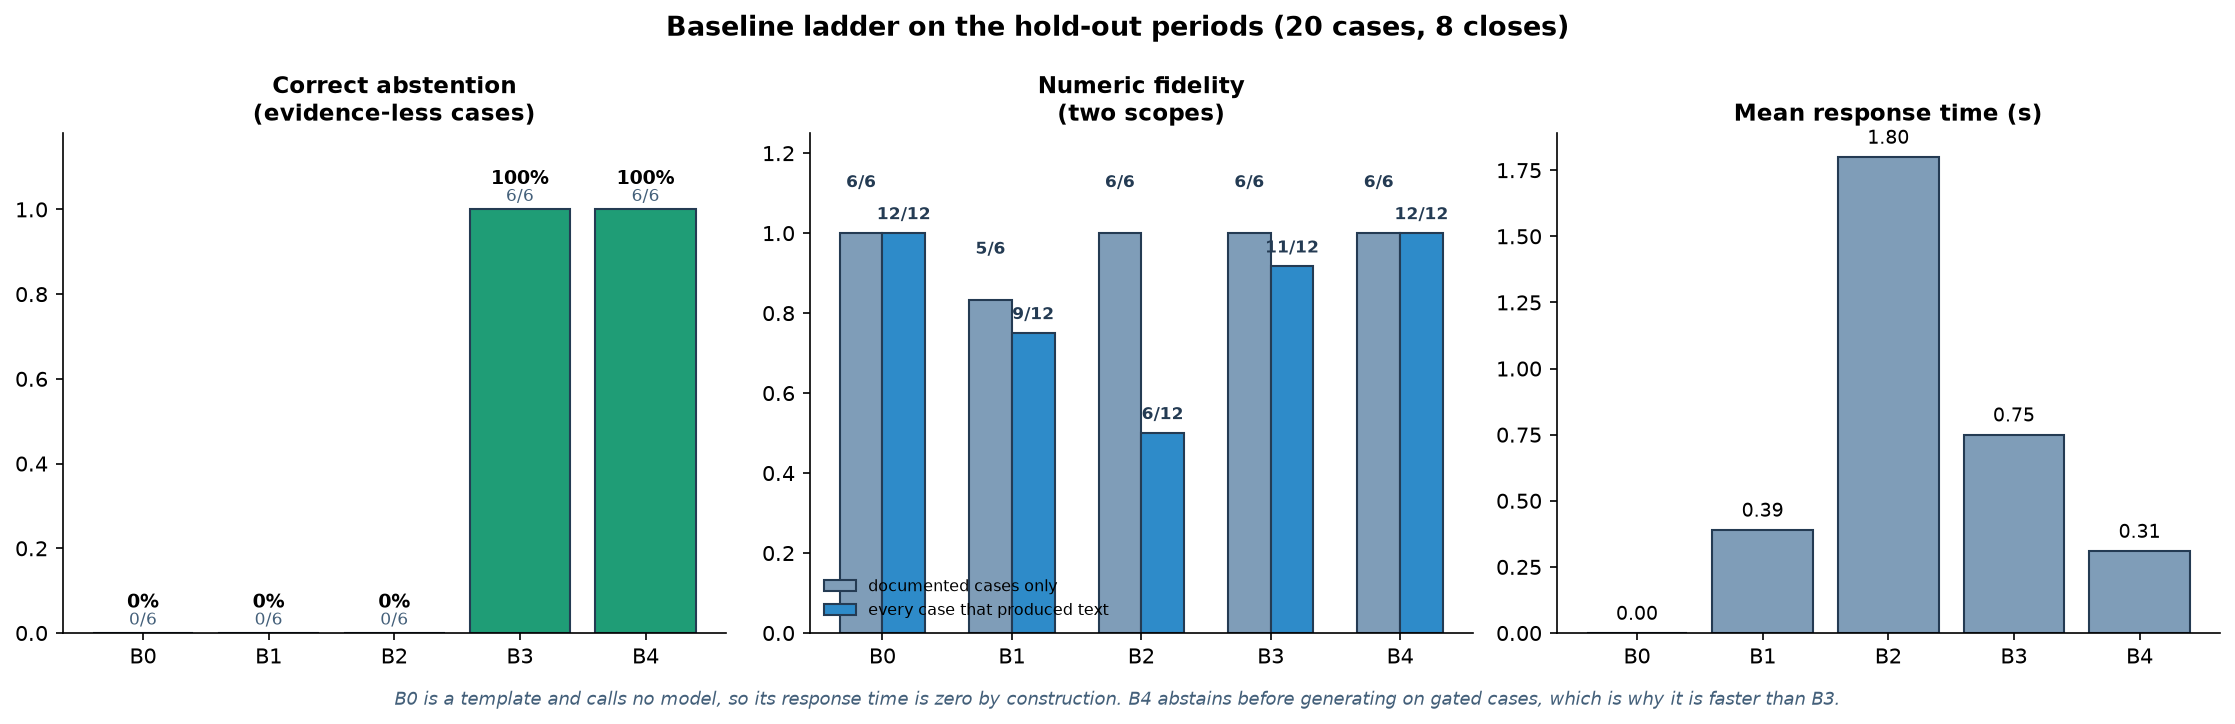

improvement_chart.png


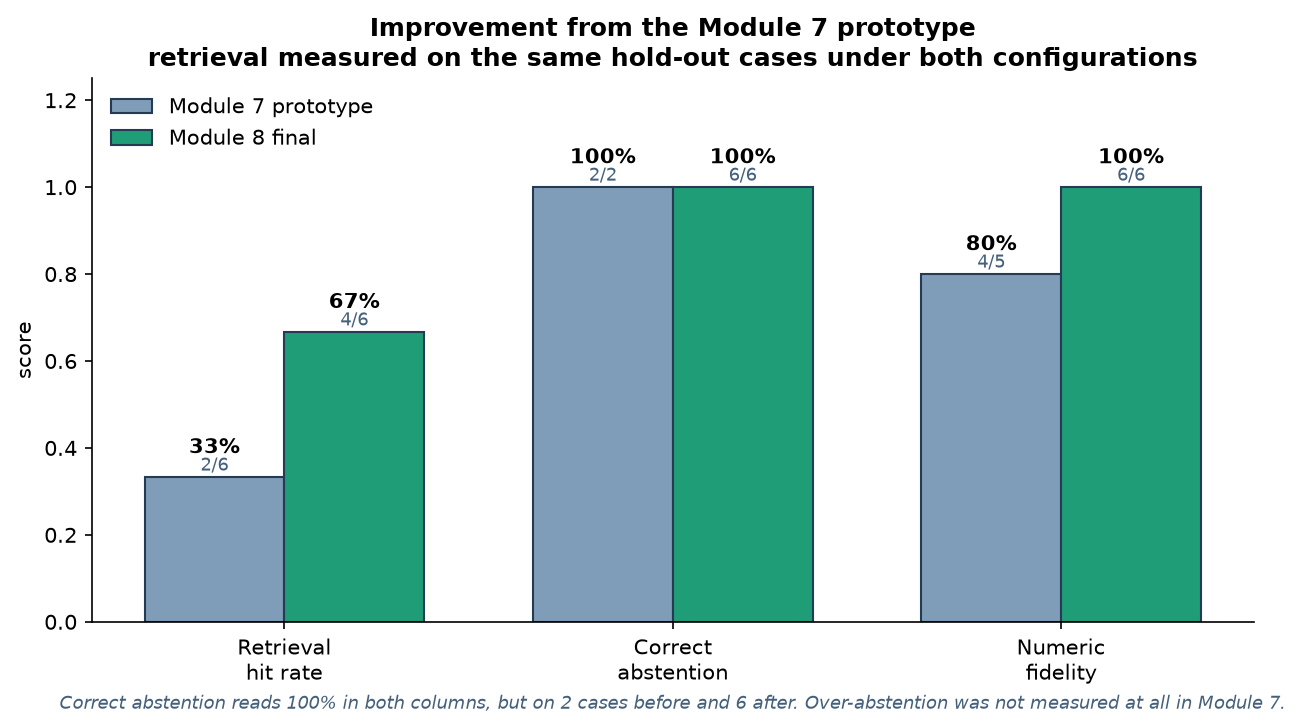

In [21]:
from IPython.display import Image, display as show

for name in ("system_architecture.png", "evaluation_chart.png",
             "improvement_chart.png"):
    print(name)
    show(Image(filename=str(IMAGES / name), width=980))

---
## 13. Exported outputs

In [22]:
for f in sorted(RESULTS.glob("*.csv")):
    df = pd.read_csv(f)
    print(f"{f.name:38} {len(df):4} rows   {', '.join(df.columns[:6])}"
          f"{' ...' if len(df.columns) > 6 else ''}")

before_after_holdout.csv                 40 rows   arm, case_id, stratum, period, account, variance_usd ...
benchmark_results.csv                     5 rows   arm, cases, retrieval_hits, retrieval_rate, numeric_fidelity, numeric_fidelity_all ...
evaluation_scores.csv                   100 rows   arm, case_id, stratum, period, account, variance_usd ...
generated_outputs.csv                   100 rows   arm, case_id, stratum, period, answer, response_time_s
improvement_comparison.csv               10 rows   Area, Module 7 prototype, Module 8 final, Evidence
parity_B3_module7_config.csv              8 rows   arm, case_id, stratum, period, account, variance_usd ...
per_period_results.csv                    8 rows   period, cases, retrieval, abstention, numeric_fidelity
retrieval_config_comparison.csv           3 rows   config, hits, n, rate, misses


---
## 14. Limitations and responsible use

**This system is a classroom prototype. Outputs should be reviewed by a human before
real-world use.**

- **The corpus is synthetic and small.** Fifteen documents is enough to make retrieval
  fail in instructive ways and far too few to estimate how it behaves against a real
  document store of thousands.
- **Retrieval is the binding constraint.** Two thirds of the planted sources are
  retrieved. Every miss becomes an abstention rather than a wrong answer, which is the
  safe direction, but an abstention is still work returned to the analyst.
- **One model, one embedding model, one seed.** No claim is made that the result
  generalises to other local models.
- **The ground truth is planted by the author.** A retrieval hit means the intended
  document was found, not that a finance reviewer would agree it was the best evidence.
- **Human review is required by design, not as a disclaimer.** The intended use is a
  first draft attached to evidence, reviewed by the cost-centre owner who is named in
  the output. Nothing here should be filed without that review.

**Privacy.** Inference runs locally through Ollama and no financial figure leaves the
machine. That is a property of the deployment, not of the model, and it would need to
be re-established in any other serving arrangement.